<a href="https://colab.research.google.com/github/sebastianvettel1212/scikit-learn-cookbook/blob/main/scikit_learn_Cookbook_Chapter4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 4 — Membangun Model dengan Metrik Jarak dan *Nearest Neighbors* (*Building Models with Distance Metrics and Nearest Neighbors*)

**Buku:** *scikit-learn Cookbook, Third Edition* — John Sukup (Packt Publishing)

Notebook ini berisi:
1. **Reproduksi kode** seluruh *recipe* Bab 4 (dari repositori resmi buku, termasuk solusi latihan),
2. **Ringkasan** tiap subbab, dan
3. **Penjelasan teori** dalam Bahasa Indonesia.

---

## Daftar Isi
0. Persiapan
1. Memahami *k-Nearest Neighbors* (KNN)
2. Gambaran Umum Metrik Jarak
3. Penyetelan Hyperparameter pada KNN
4. Mengevaluasi Performa KNN
5. KNN untuk Regresi dan Pentingnya Scaling (materi tambahan)
6. Latihan Praktik
7. Ringkasan Bab

---

## Pengantar
Bab ini membahas model yang paling intuitif dalam *machine learning*: **KNN**. Idenya sederhana, yaitu *"katakan siapa tetanggamu, maka kutahu siapa kamu"*. Titik data baru diklasifikasikan atau diprediksi berdasarkan titik-titik pelatihan yang **paling dekat** dengannya. Karena itu, seluruh performa KNN bergantung pada bagaimana **"dekat"** didefinisikan, yaitu **metrik jarak**.

## 0. Persiapan

In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn

In [2]:
import numpy as np
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

---
## 1. Memahami *k-Nearest Neighbors* (KNN)

### Getting ready
KNN adalah algoritma yang sederhana tetapi kuat:
- Membuat prediksi berdasarkan **$k$ contoh latih terdekat**.
- **Non-parametrik**: tidak mengasumsikan bentuk distribusi data.
- Dapat dipakai untuk **klasifikasi** maupun **regresi**.

Dataset yang dipakai: **Iris** (150 bunga, 4 fitur ukuran kelopak/mahkota, 3 spesies).

In [3]:
# Load libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)

### How to do it
Implementasi KNN dasar mengikuti pola desain yang sama seperti model lain di buku ini: buat objek, `fit()`, `predict()`.

In [4]:
# Load libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create and train a basic KNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


### How it works
Algoritma KNN bekerja sebagai berikut:
1. **Menyimpan** seluruh contoh latih. KNN adalah *lazy learner*: `fit()` hampir tidak melakukan "belajar", hanya menyimpan data (dan membangun struktur indeks).
2. Untuk setiap titik baru:
   - **hitung jarak** ke seluruh contoh latih,
   - ambil **$k$ tetangga terdekat**,
   - **klasifikasi:** voting mayoritas; **regresi:** rata-rata nilai target tetangga.

### Teori: pengaruh nilai $k$ (*bias–variance trade-off*)
| $k$ | Perilaku | Risiko |
|---|---|---|
| **Kecil** (mis. 1) | Batas keputusan sangat rumit, mengikuti noise | *Overfitting* (variansi tinggi) |
| **Besar** | Batas keputusan halus | *Underfitting* (bias tinggi) |

Nilai $k$ ganjil membantu menghindari seri pada voting dua kelas. Nilai $k$ yang tepat dipilih lewat *cross-validation* (bagian 3).

### Teori: kelemahan KNN
- **Prediksi lambat** pada data besar (menghitung jarak ke semua titik).
- Sensitif terhadap **skala fitur** dan fitur yang tidak relevan.
- Terkena ***curse of dimensionality***: pada dimensi tinggi semua titik tampak "sama jauh", sehingga konsep tetangga terdekat kehilangan makna (lihat Bab 3 untuk reduksi dimensi).

### Key Ideas
- KNN = prediksi dari $k$ tetangga terdekat; tanpa asumsi distribusi.
- $k$ kecil → overfitting; $k$ besar → underfitting.

---
## 2. Gambaran Umum Metrik Jarak

### Teori
Hasil KNN sangat dipengaruhi cara kita mengukur kedekatan. Metrik yang umum untuk dua titik $a=(a_1,\dots,a_n)$ dan $b=(b_1,\dots,b_n)$:

| Metrik | Rumus | Karakter |
|---|---|---|
| **Euclidean** ($L_2$) | $\sqrt{\sum_i (a_i-b_i)^2}$ | Jarak "garis lurus", metrik default |
| **Manhattan** ($L_1$) | $\sum_i \lvert a_i-b_i\rvert$ | Jarak "blok kota", lebih tahan terhadap outlier |
| **Minkowski** | $\left(\sum_i \lvert a_i-b_i\rvert^p\right)^{1/p}$ | Generalisasi; $p=1$ Manhattan, $p=2$ Euclidean |
| **Cosine** | $1-\dfrac{a\cdot b}{\lVert a\rVert\lVert b\rVert}$ | Mengukur **arah**, bukan besar; umum untuk teks |

> Pada scikit-learn, `metric='minkowski'` dengan parameter default `p=2` **identik dengan Euclidean**. Itu sebabnya kedua metrik tersebut menghasilkan akurasi yang sama pada eksperimen di bawah.

### Getting ready
Kita membuat dua dataset sintetis untuk melihat perbedaan antar-metrik: **lingkaran ber-noise** (`make_circles`) dan pola **papan catur**.

In [5]:
# Load libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Create two synthetic datasets that highlight metric differences
n_samples = 300

# Circular dataset with high noise (Euclidean distance should work better)
X_circles, y_circles = make_circles(n_samples=n_samples, noise=0.3, factor=0.3)
X_circles_train, X_circles_test, y_circles_train, y_circles_test = train_test_split(
    X_circles, y_circles, test_size=0.2, random_state=2024
)

# Checkerboard pattern dataset (Manhattan distance should work better)
x = np.linspace(0, 4, int(np.sqrt(n_samples)))
y = np.linspace(0, 4, int(np.sqrt(n_samples)))
xx, yy = np.meshgrid(x, y)
X_moons = np.column_stack((xx.ravel(), yy.ravel()))
y_moons = np.mod(np.floor(xx.ravel()) + np.floor(yy.ravel()), 2)
X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=2024
)

### How to do it
Kita mengulang tiap metrik, membangun dua classifier KNN (satu per dataset), lalu memvisualisasikan data beserta akurasinya.

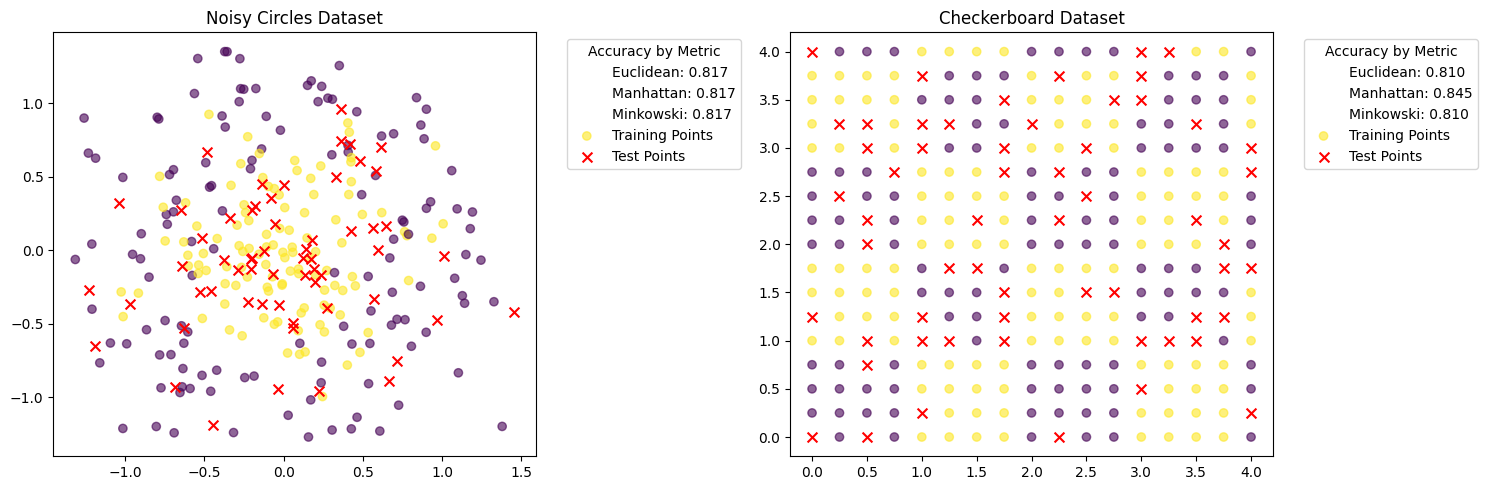

In [6]:
# Compare different distance metrics on both datasets
metrics = ['euclidean', 'manhattan', 'minkowski']
results = {'circles': {}, 'moons': {}}

for metric in metrics:
    # Test on "circles" dataset
    knn_circles = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_circles.fit(X_circles_train, y_circles_train)
    y_pred_circles = knn_circles.predict(X_circles_test)
    results['circles'][metric] = accuracy_score(y_circles_test, y_pred_circles)

    # Test on "moons" dataset
    knn_moons = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_moons.fit(X_moons_train, y_moons_train)
    y_pred_moons = knn_moons.predict(X_moons_test)
    results['moons'][metric] = accuracy_score(y_moons_test, y_pred_moons)

# Set up plot specs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot circles dataset
scatter1_train = ax1.scatter(X_circles_train[:, 0], X_circles_train[:, 1], c=y_circles_train, cmap='viridis', alpha=0.6, label='Training Points')
scatter1_test = ax1.scatter(X_circles_test[:, 0], X_circles_test[:, 1], color='red', marker='x', s=50, label='Test Points')
ax1.set_title('Noisy Circles Dataset')

# Create dummy lines for legend
lines1 = [plt.Line2D([0], [0], color='white') for _ in metrics]
legend_text1 = [
    f"Euclidean: {results['circles']['euclidean']:.3f}",
    f"Manhattan: {results['circles']['manhattan']:.3f}",
    f"Minkowski: {results['circles']['minkowski']:.3f}"
]
ax1.legend(lines1 + [scatter1_train, scatter1_test], legend_text1 + ['Training Points', 'Test Points'],
          title='Accuracy by Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot moons dataset
scatter2_train = ax2.scatter(X_moons_train[:, 0], X_moons_train[:, 1], c=y_moons_train, cmap='viridis', alpha=0.6, label='Training Points')
scatter2_test = ax2.scatter(X_moons_test[:, 0], X_moons_test[:, 1], color='red', marker='x', s=50, label='Test Points')
ax2.set_title('Checkerboard Dataset')

# Create dummy lines for legend
lines2 = [plt.Line2D([0], [0], color='white') for _ in metrics]
legend_text2 = [
    f"Euclidean: {results['moons']['euclidean']:.3f}",
    f"Manhattan: {results['moons']['manhattan']:.3f}",
    f"Minkowski: {results['moons']['minkowski']:.3f}"
]
ax2.legend(lines2 + [scatter2_train, scatter2_test], legend_text2 + ['Training Points', 'Test Points'],
          title='Accuracy by Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Interpretasi:** pada pola papan catur (data berbentuk grid, hasilnya deterministik), Manhattan mencapai akurasi ≈ 0,845 sedangkan Euclidean dan Minkowski ($p=2$) ≈ 0,810, jadi pada data berbentuk grid jarak "blok kota" sedikit lebih cocok. Pada lingkaran ber-noise, perbedaan antar-metrik kecil. Dataset lingkaran dibuat secara acak tanpa `random_state`, sehingga angkanya dapat sedikit berbeda setiap dijalankan. Pelajaran utamanya: **tidak ada metrik yang selalu terbaik**; pilihan bergantung pada geometri data, sehingga sebaiknya dibandingkan secara empiris.

### Key Ideas
- Metrik jarak menentukan siapa "tetangga" sebuah titik.
- Minkowski dengan $p=2$ sama dengan Euclidean; $p=1$ sama dengan Manhattan.
- Pilih metrik berdasarkan karakter data lalu verifikasi dengan validasi.

---
## 3. Penyetelan Hyperparameter pada KNN

Penyetelan hyperparameter adalah langkah penting untuk mengoptimalkan model, termasuk KNN.

### Getting ready
Kita memakai dataset Iris lagi, dan menyetel: **jumlah tetangga** (`n_neighbors`), apakah tetangga **diberi bobot berdasarkan jarak** (`weights`), dan **metrik jarak** (`metric`).

- `weights='uniform'`: semua tetangga bersuara sama.
- `weights='distance'`: tetangga yang lebih dekat bersuara lebih besar (bobot $\propto 1/\text{jarak}$).

### How to do it
**Grid search** mencoba **seluruh kombinasi** hyperparameter dan mengembalikan kombinasi terbaik. Digabung dengan **cross-validation** ($k$-fold, di sini `cv=5`), sehingga skor tiap kombinasi dihitung dari rata-rata lima lipatan data latih, bukan satu pemisahan saja. Pada contoh ini ada $5\times2\times2=20$ kombinasi, jadi total $20\times5=100$ model dilatih.

In [7]:
# Load libraries
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Create KNN classifier
knn = KNeighborsClassifier()

# Define parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create grid search
grid_search = GridSearchCV(
    knn, param_grid, cv=5, scoring='accuracy'
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Print best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best cross-validation score: 0.9916666666666668


**Interpretasi:** `best_params_` adalah kombinasi terbaik dan `best_score_` adalah rata-rata akurasi cross-validation untuk kombinasi itu. Bila beberapa kombinasi menghasilkan skor yang sama, scikit-learn memilih yang pertama dalam urutan pencarian.

### Key Ideas
- `GridSearchCV` = mencoba semua kombinasi + validasi silang.
- Setelah selesai, `grid_search.best_estimator_` sudah dilatih ulang dengan parameter terbaik dan siap dipakai.

---
## 4. Mengevaluasi Performa KNN

Evaluasi membantu kita mengetahui seberapa baik prediksi model dan di mana kelemahannya. Tiga pendekatan yang dipakai:
- **Skor cross-validation:** estimasi performa yang lebih stabil daripada satu pemisahan data.
- **Learning curve:** performa terhadap ukuran data latih, untuk mendiagnosis *overfitting/underfitting* (apakah menambah data akan membantu).
- **Confusion matrix & classification report:** rincian kesalahan per kelas.

### Metrik klasifikasi (teori)
Untuk satu kelas dengan TP, FP, FN, TN:
$$\text{Precision}=\frac{TP}{TP+FP},\quad \text{Recall}=\frac{TP}{TP+FN},\quad F_1=\frac{2\cdot P\cdot R}{P+R}$$
- **Precision:** dari yang diprediksi kelas itu, berapa yang benar.
- **Recall:** dari yang sebenarnya kelas itu, berapa yang berhasil terdeteksi.
- **F1:** rata-rata harmonik precision dan recall.

In [8]:
# Load libraries
from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

### How to do it...
Kita jalankan ketiga pendekatan pada model terbaik hasil grid search.

Cross-validation scores: [0.95833333 1.         1.         1.         1.        ]
Mean CV score: 0.9916666666666668
Standard deviation: 0.016666666666666653


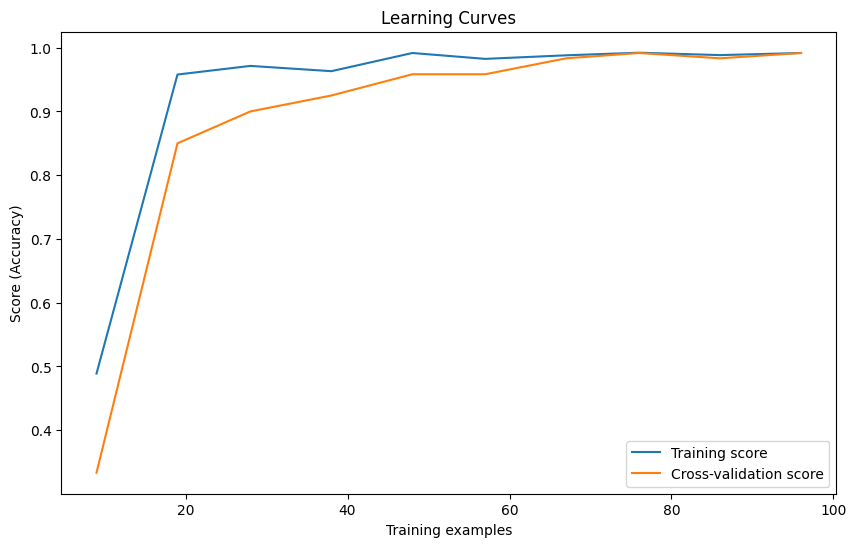

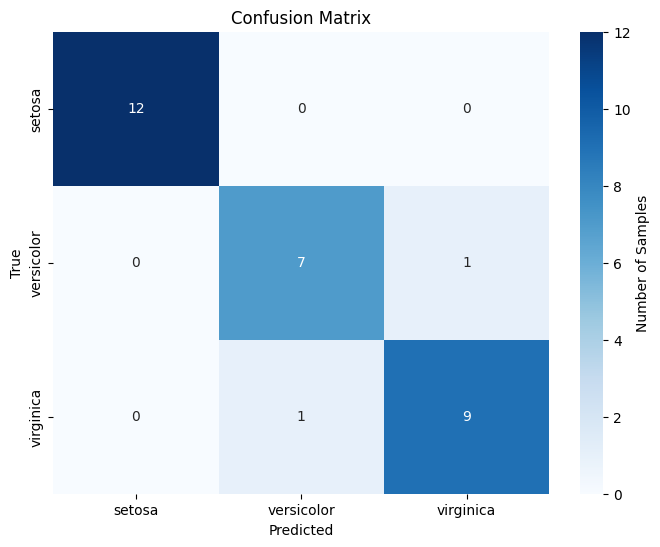


Classification Report:


,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,12
versicolor,0.875,0.875,0.875,8
virginica,0.900,0.900,0.900,10
accuracy,0.933,0.933,0.933,1
macro avg,0.925,0.925,0.925,30
weighted avg,0.933,0.933,0.933,30


In [9]:
# Get cross-validation scores
cv_scores = cross_val_score(grid_search.best_estimator_, X_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

# Generate learning curves
train_sizes, train_scores, test_scores = learning_curve(
    grid_search.best_estimator_, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5
)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Score (Accuracy)')
plt.legend(loc='best')
plt.title('Learning Curves')
plt.show()

# Make predictions on test set
y_pred = grid_search.best_estimator_.predict(X_test)

# Get class names from iris dataset
class_names = iris.target_names

# Generate and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Get classification report as a dict
report_dict = classification_report(y_test, y_pred,
                                  target_names=class_names,
                                  output_dict=True)

# Create a DataFrame for better visualization
report_df = pd.DataFrame(report_dict).transpose()

# Style the DataFrame
styled_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print("\nClassification Report:")
display(styled_df)

**Cara membaca hasilnya:**
- **Skor CV** dan simpangan bakunya menunjukkan rata-rata dan stabilitas akurasi antar-lipatan.
- **Learning curve:** bila skor validasi sudah mendatar saat data ditambah, menambah data tidak banyak membantu. Jarak besar antara skor latih dan skor validasi menandakan *overfitting*.
- **Confusion matrix:** diagonal = prediksi benar, di luar diagonal = kesalahan. Pada Iris, kesalahan umumnya terjadi antara *versicolor* dan *virginica*, sedangkan *setosa* sangat mudah dipisahkan.
- **Classification report:** precision, recall, dan F1 per kelas (`support` = jumlah sampel uji kelas itu). Baris `accuracy` berlaku untuk keseluruhan model.

> Dataset Iris kecil (hanya 30 sampel uji), sehingga angka akurasi sangat peka terhadap pembagian data. Satu kesalahan prediksi saja mengubah akurasi sekitar 3,3 poin persentase.

### Key Ideas
- Gunakan beberapa alat evaluasi sekaligus: CV, learning curve, confusion matrix.
- Akurasi saja tidak cukup; periksa precision, recall, dan F1 per kelas.

---
## 5. KNN untuk Regresi dan Pentingnya Scaling (materi tambahan)

> Bagian ini adalah **tambahan** (tidak ada di kode buku) untuk melengkapi teori KNN yang disebut pada pengantar bab.

### a) Pengaruh scaling
Karena KNN berbasis jarak, fitur berskala besar mendominasi perhitungan jarak. Kita bandingkan KNN **tanpa** dan **dengan** `StandardScaler` pada dataset Wine, yang fiturnya berskala sangat berbeda (mis. `proline` ratusan, `hue` sekitar 1).

In [10]:
# Tambahan (tidak ada di kode buku): efek scaling pada KNN
from sklearn.datasets import load_wine
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

Xw, yw = load_wine(return_X_y=True)
Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(Xw, yw, test_size=0.2, random_state=2024, stratify=yw)

knn_raw = KNeighborsClassifier(n_neighbors=5).fit(Xw_tr, yw_tr)
knn_scaled = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)).fit(Xw_tr, yw_tr)

print('Akurasi tanpa scaling :', round(knn_raw.score(Xw_te, yw_te), 3))
print('Akurasi dengan scaling:', round(knn_scaled.score(Xw_te, yw_te), 3))

Akurasi tanpa scaling : 0.639
Akurasi dengan scaling: 0.944


**Interpretasi:** setelah fitur distandardisasi, akurasi KNN meningkat tajam, karena fitur seperti `proline` tidak lagi mendominasi jarak.

### b) Memilih $k$: kurva akurasi terhadap $k$

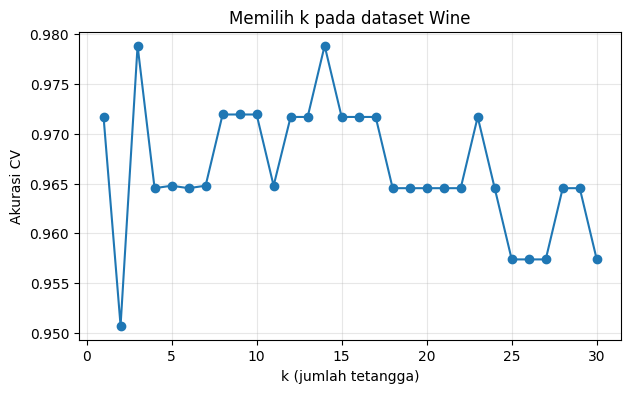

k terbaik: 3 | akurasi CV: 0.979


In [11]:
# Tambahan (tidak ada di kode buku): akurasi cross-validation untuk berbagai nilai k
ks = range(1, 31)
cv_means = [cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)),
                            Xw_tr, yw_tr, cv=5).mean() for k in ks]

plt.figure(figsize=(7, 4))
plt.plot(ks, cv_means, marker='o')
plt.xlabel('k (jumlah tetangga)')
plt.ylabel('Akurasi CV')
plt.title('Memilih k pada dataset Wine')
plt.grid(alpha=0.3)
plt.show()
print('k terbaik:', list(ks)[int(np.argmax(cv_means))], '| akurasi CV:', round(max(cv_means), 3))

**Interpretasi:** akurasi biasanya naik dari $k=1$ (rawan noise) lalu mendatar atau menurun pada $k$ yang terlalu besar (terlalu halus). Titik tertinggi menjadi kandidat $k$ terbaik.

### c) KNN untuk regresi
`KNeighborsRegressor` memprediksi dengan **rata-rata target** dari $k$ tetangga terdekat.

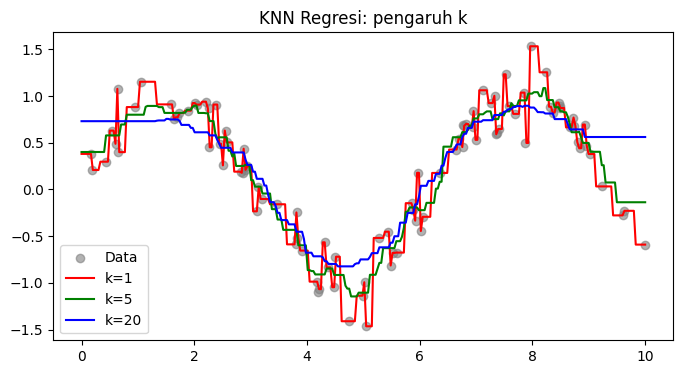

In [12]:
# Tambahan (tidak ada di kode buku): KNN regresi
from sklearn.neighbors import KNeighborsRegressor

rng = np.random.RandomState(2024)
Xr = np.sort(rng.uniform(0, 10, 100)).reshape(-1, 1)
yr = np.sin(Xr).ravel() + rng.normal(0, 0.2, 100)
x_grid = np.linspace(0, 10, 300).reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.scatter(Xr, yr, color='gray', alpha=0.6, label='Data')
for k, c in zip([1, 5, 20], ['red', 'green', 'blue']):
    reg = KNeighborsRegressor(n_neighbors=k).fit(Xr, yr)
    plt.plot(x_grid, reg.predict(x_grid), color=c, label=f'k={k}')
plt.legend()
plt.title('KNN Regresi: pengaruh k')
plt.show()

**Interpretasi:** $k=1$ mengikuti setiap titik noise (overfitting); $k=20$ terlalu halus; $k=5$ menjadi kompromi yang baik.

---
## 6. Latihan Praktik: Model KNN

### Latihan 1: Membangun Classifier KNN
Bangun KNN pada dataset **Breast Cancer**: muat data, bagi, scaling, latih, prediksi, evaluasi.

In [13]:
# Load libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Load the Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Preprocess the Data
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and Train the KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Make Predictions
y_pred = knn.predict(X_test_scaled)

# Evaluate Performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.947

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



**Interpretasi:** setelah scaling, KNN mencapai akurasi tinggi (sekitar 95%) pada dua kelas (ganas/jinak). Pada konteks medis, **recall** untuk kelas yang berbahaya sering lebih penting daripada akurasi keseluruhan.

### Latihan 2: Penyetelan Hyperparameter dengan Grid Search
Bandingkan berbagai konfigurasi KNN pada dataset sintetis 3 kelas.

In [14]:
# Load libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Load a different dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15,
                         n_redundant=5, n_classes=3, random_state=42)

# Preprocess the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Set up grid search:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')

# Fit grid search
grid_search.fit(X_train_scaled, y_train)

# Evaluate best model
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)
y_pred = grid_search.predict(X_test_scaled)
print("\nTest Set Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best cross-validation score: 0.8574999999999999

Test Set Performance:
Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89        70
           1       0.91      0.96      0.93        73
           2       0.79      0.81      0.80        57

    accuracy                           0.88       200
   macro avg       0.88      0.87      0.87       200
weighted avg       0.88      0.88      0.88       200



**Interpretasi:** skor CV adalah estimasi pada data latih, sedangkan akurasi uji adalah skor pada data yang belum pernah dilihat. Keduanya perlu mirip agar kita yakin tidak ada overfitting terhadap proses penyetelan.

### Latihan 3: Mengevaluasi Classifier KNN
Evaluasi KNN dengan *confusion matrix* dan *classification report* pada data sintetis 3 kelas.

In [15]:
# Load libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the Dataset
# Create a synthetic dataset with 3 classes and some informative/redundant features
X, y = make_classification(n_samples=1000,
                         n_features=15,
                         n_informative=10,
                         n_redundant=5,
                         n_classes=3,
                         n_clusters_per_class=2,
                         random_state=42)

# Preprocess the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and Train the KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Make Predictions
y_pred = knn.predict(X_test_scaled)

# Evaluate Performance
print("Model Performance Evaluation")
print("-" * 30)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Performance Evaluation
------------------------------
Accuracy Score: 0.850

Confusion Matrix:
[[56  6  6]
 [ 4 56  5]
 [ 6  3 58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        68
           1       0.86      0.86      0.86        65
           2       0.84      0.87      0.85        67

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



**Interpretasi:** *confusion matrix* menunjukkan pasangan kelas yang paling sering tertukar, informasi yang tidak tampak dari satu angka akurasi.

---
## 7. Ringkasan Bab

Bab ini membahas **KNN** (model berbasis jarak yang intuitif), **metrik jarak** (Euclidean, Manhattan, Minkowski), **penyetelan hyperparameter** dengan `GridSearchCV`, dan **evaluasi** model dengan CV, learning curve, serta confusion matrix. Kekuatan KNN adalah kesederhanaan dan fleksibilitasnya; kelemahannya adalah sensitivitas terhadap skala fitur, dimensi tinggi, dan prediksi yang lambat pada data besar.

### Rangkuman Konsep dan Fungsi
| Subbab | Konsep utama | Kelas/Fungsi scikit-learn |
|---|---|---|
| KNN | Voting/rata-rata $k$ tetangga terdekat | `KNeighborsClassifier`, `KNeighborsRegressor` |
| Metrik jarak | Euclidean, Manhattan, Minkowski | `metric=`, `p=` |
| Hyperparameter | `n_neighbors`, `weights`, `metric` | `GridSearchCV` |
| Evaluasi | CV, learning curve, confusion matrix, precision/recall/F1 | `cross_val_score`, `learning_curve`, `confusion_matrix`, `classification_report` |
| Scaling | Menyeimbangkan kontribusi fitur | `StandardScaler`, `make_pipeline` |
| Latihan | Klasifikasi, grid search, evaluasi | `load_breast_cancer`, `make_classification` |

**Pesan utama:** KNN sangat bergantung pada definisi "kedekatan", jadi **lakukan scaling, pilih metrik, dan setel $k$ dengan validasi silang**.